## 1. Install libraries

In [117]:
!pip install numpy pandas matplotlib seaborn scikit-learn scikit-learn-extra -q

## 2. Library Imports

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from time import time

from sklearn.datasets import load_iris
from sklearn.model_selection import KFold
from sklearn.preprocessing import RobustScaler, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering

# Metrics for clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

warnings.filterwarnings('ignore')

## 3. Dataset Import

In [119]:
# Loading the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)

print("Dataset shape:", X.shape)
print("\nFeature names:")
print(X.columns.tolist())
print("\nDataset info:")
print(X.describe())

Dataset shape: (150, 4)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Dataset info:


       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [120]:
X

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


## 4. Data preprocessing

In [121]:
# Check for missing values
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


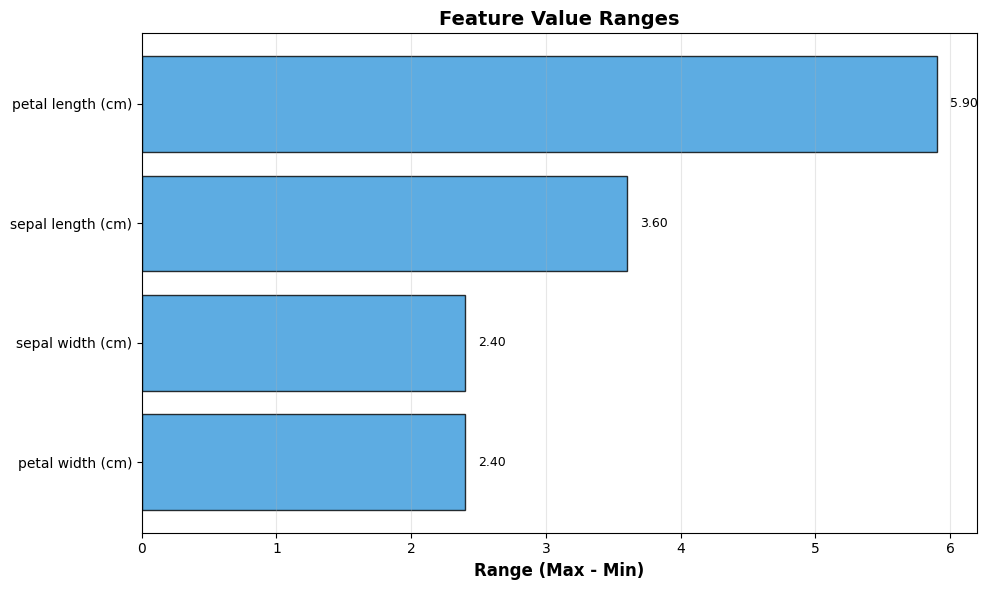

Feature scaling analysis completed.


In [122]:
# Check feature scaling

# Calculate min and max for each feature
feature_ranges = pd.DataFrame({
    'Feature': X.columns,
    'Min': X.min().values,
    'Max': X.max().values,
    'Range': (X.max() - X.min()).values
})

# Sort by range in descending order
feature_ranges = feature_ranges.sort_values('Range', ascending=True)

# Create barplot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(feature_ranges))
ax.barh(y_pos, feature_ranges['Range'], color='#3498db', alpha=0.8, edgecolor='black')

ax.set_yticks(y_pos)
ax.set_yticklabels(feature_ranges['Feature'])
ax.set_xlabel('Range (Max - Min)', fontsize=12, fontweight='bold')
ax.set_title('Feature Value Ranges', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(feature_ranges.iterrows()):
    ax.text(row['Range'] + 0.1, i, f"{row['Range']:.2f}", va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('feature_ranges.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature scaling analysis completed.")

Feature scaling will be applied within the 5-fold CV loop.

## 5. Exploratory Data Analysis (EDA)

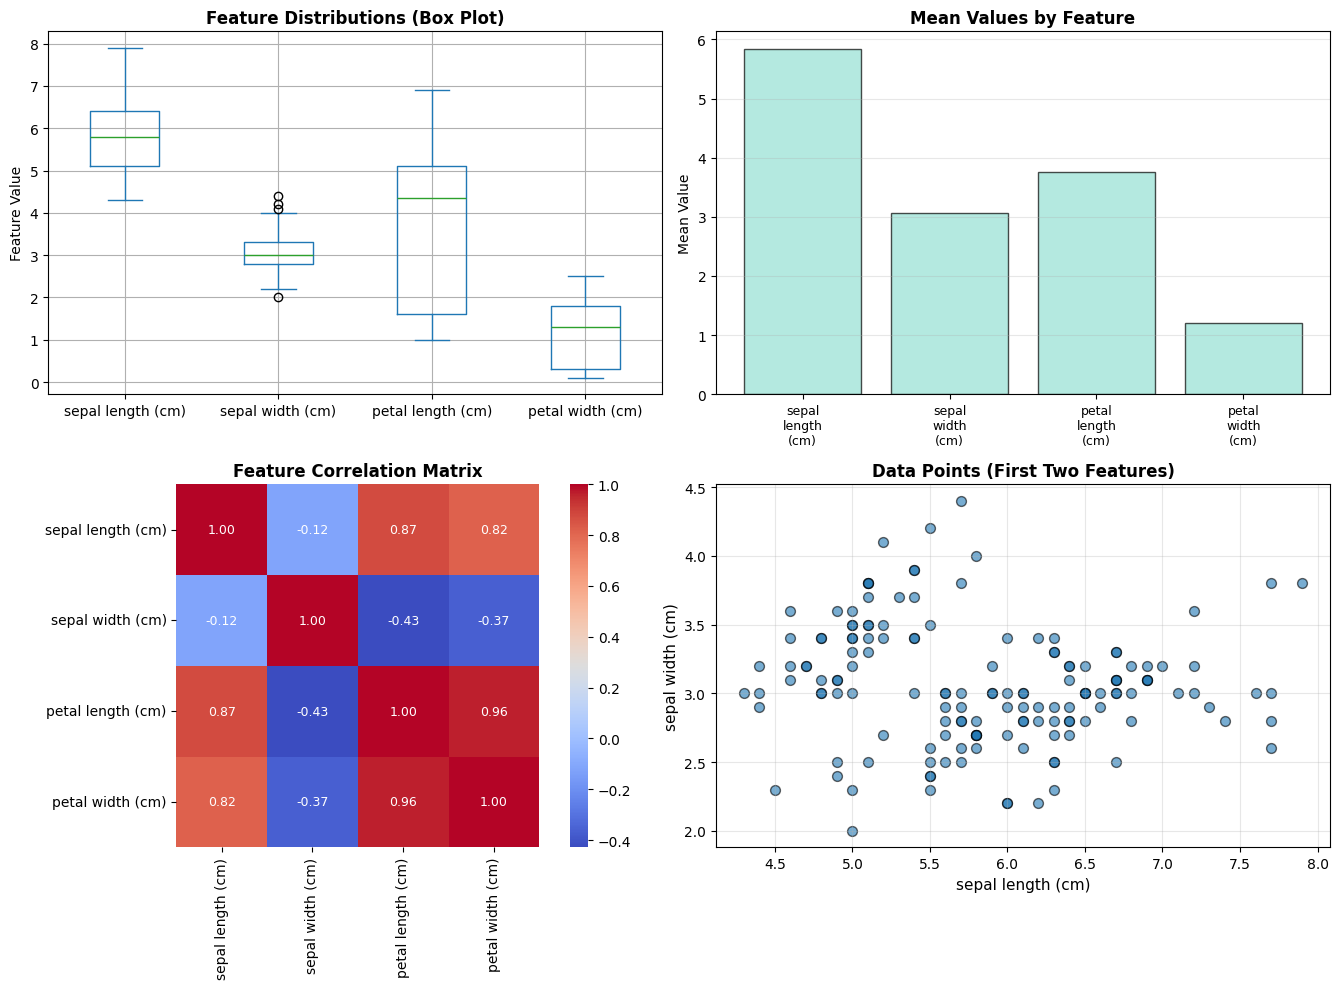

In [123]:
# Create a figure with subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 5.1 - Feature distributions
ax = axes[0, 0]
X.plot(kind='box', ax=ax, grid=True)
ax.set_title('Feature Distributions (Box Plot)', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature Value')

# 5.2 - Feature statistics
ax = axes[0, 1]
feature_means = X.mean()
ax.bar(range(len(feature_means)), feature_means.values, color='#95E1D3', alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(feature_means)))
ax.set_xticklabels([name.replace(' ', '\n') for name in feature_means.index], fontsize=9)
ax.set_title('Mean Values by Feature', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.grid(axis='y', alpha=0.3)

# 5.3 - Feature correlation heatmap
ax = axes[1, 0]
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            cbar=True, ax=ax, square=True, annot_kws={'size': 9})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')

# 5.4 - PCA-like visualization (first two features)
ax = axes[1, 1]
scatter = ax.scatter(X.iloc[:, 0], X.iloc[:, 1], alpha=0.6, edgecolor='black', s=50)
ax.set_xlabel(X.columns[0], fontsize=11)
ax.set_ylabel(X.columns[1], fontsize=11)
ax.set_title('Data Points (First Two Features)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

#print("EDA completed and saved as 'eda_overview.png'")

## 6. Model Training with 5-Fold Cross Validation

In [124]:
def run_kmeans_kfold(X, cv, n_clusters=3, scaler_class=RobustScaler, random_state=42, n_init=10, method_name='K-Means'):
    """
    Run K-Means clustering with k-fold cross validation.
    
    Parameters:
    -----------
    X : DataFrame
        Feature data
    cv : KFold object
        Cross-validation object
    n_clusters : int
        Number of clusters
    scaler_class : sklearn scaler class
        Scaler to use (e.g., RobustScaler, StandardScaler, MinMaxScaler)
    random_state : int
        Random state for reproducibility
    n_init : int
        Number of time the k-means algorithm will run
    method_name : str
        Name to use in results table
        
    Returns:
    --------
    dict : Dictionary with all metrics and times
    """
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=n_init)
    
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    train_times = []
    predict_times = []
    inertias = []
    
    print(f"Running 5-Fold Cross Validation with {method_name} (k={n_clusters})...\n")
    
    for fold_num, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        
        # Apply scaler to training data
        scaler = scaler_class()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train K-means on training data
        start_time = time()
        kmeans.fit(X_train_scaled)
        train_time = time() - start_time
        
        # Predict labels on test data
        start_time = time()
        test_labels = kmeans.predict(X_test_scaled)
        predict_time = time() - start_time
        
        # Calculate clustering metrics
        silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
        train_times.append(train_time)
        predict_times.append(predict_time)
        inertias.append(kmeans.inertia_)
    
    print("=" * 60)
    print(f"CROSS-VALIDATION SUMMARY - {method_name.upper()}")
    print("=" * 60)
    print(f"Silhouette Score: {np.mean(silhouette_scores):.4f} (+/- {np.std(silhouette_scores):.4f})")
    print(f"Davies-Bouldin Index: {np.mean(davies_bouldin_scores):.4f} (+/- {np.std(davies_bouldin_scores):.4f})")
    print(f"Calinski-Harabasz Index: {np.mean(calinski_harabasz_scores):.4f} (+/- {np.std(calinski_harabasz_scores):.4f})")
    print(f"Avg Training Time: {np.mean(train_times):.6f}s")
    print(f"Avg Prediction Time: {np.mean(predict_times):.6f}s")
    
    return {
        'silhouette_scores': silhouette_scores,
        'davies_bouldin_scores': davies_bouldin_scores,
        'calinski_harabasz_scores': calinski_harabasz_scores,
        'train_times': train_times,
        'predict_times': predict_times,
        'inertias': inertias
    }


def run_kmedoids_kfold(X, cv, n_clusters=3, scaler_class=RobustScaler, random_state=42, method='pam', method_name='K-Medoids'):
    """
    Run K-Medoids clustering with k-fold cross validation.
    
    Parameters:
    -----------
    X : DataFrame
        Feature data
    cv : KFold object
        Cross-validation object
    n_clusters : int
        Number of clusters
    scaler_class : sklearn scaler class
        Scaler to use (e.g., RobustScaler, StandardScaler, MinMaxScaler)
    random_state : int
        Random state for reproducibility
    method : str
        Method for K-Medoids ('pam' or 'alternate')
    method_name : str
        Name to use in results table
        
    Returns:
    --------
    dict : Dictionary with all metrics and times
    """
    kmedoids = KMedoids(n_clusters=n_clusters, random_state=random_state, method=method)
    
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    train_times = []
    predict_times = []
    inertias = []
    
    print(f"Running 5-Fold Cross Validation with {method_name} (k={n_clusters})...\n")
    
    for fold_num, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        
        # Apply scaler to training data
        scaler = scaler_class()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train K-medoids on training data
        start_time = time()
        kmedoids.fit(X_train_scaled)
        train_time = time() - start_time
        
        # Predict labels on test data
        start_time = time()
        test_labels = kmedoids.predict(X_test_scaled)
        predict_time = time() - start_time
        
        # Calculate clustering metrics
        silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
        train_times.append(train_time)
        predict_times.append(predict_time)
        inertias.append(kmedoids.inertia_)
    
    print("=" * 60)
    print(f"CROSS-VALIDATION SUMMARY - {method_name.upper()}")
    print("=" * 60)
    print(f"Silhouette Score: {np.mean(silhouette_scores):.4f} (+/- {np.std(silhouette_scores):.4f})")
    print(f"Davies-Bouldin Index: {np.mean(davies_bouldin_scores):.4f} (+/- {np.std(davies_bouldin_scores):.4f})")
    print(f"Calinski-Harabasz Index: {np.mean(calinski_harabasz_scores):.4f} (+/- {np.std(calinski_harabasz_scores):.4f})")
    print(f"Avg Training Time: {np.mean(train_times):.6f}s")
    print(f"Avg Prediction Time: {np.mean(predict_times):.6f}s")
    
    return {
        'silhouette_scores': silhouette_scores,
        'davies_bouldin_scores': davies_bouldin_scores,
        'calinski_harabasz_scores': calinski_harabasz_scores,
        'train_times': train_times,
        'predict_times': predict_times,
        'inertias': inertias
    }


def run_hierarchical_kfold(X, cv, n_clusters=3, scaler_class=RobustScaler, linkage='ward', method_name='Hierarchical'):
    """
    Run Hierarchical clustering with k-fold cross validation.
    
    Parameters:
    -----------
    X : DataFrame
        Feature data
    cv : KFold object
        Cross-validation object
    n_clusters : int
        Number of clusters
    scaler_class : sklearn scaler class
        Scaler to use (e.g., RobustScaler, StandardScaler, MinMaxScaler)
    linkage : str
        Linkage criterion ('ward', 'complete', 'average', 'single')
    method_name : str
        Name to use in results table
        
    Returns:
    --------
    dict : Dictionary with all metrics and times (no inertias)
    """
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    train_times = []
    predict_times = []
    
    print(f"Running 5-Fold Cross Validation with {method_name} (k={n_clusters}, linkage={linkage})...\n")
    
    for fold_num, (train_idx, test_idx) in enumerate(cv.split(X), 1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        
        # Apply scaler to training data
        scaler = scaler_class()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train Hierarchical clustering on training data
        start_time = time()
        hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        train_labels = hierarchical.fit_predict(X_train_scaled)
        train_time = time() - start_time
        
        # Predict labels on test data (refit on test data)
        start_time = time()
        hierarchical_test = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        test_labels = hierarchical_test.fit_predict(X_test_scaled)
        predict_time = time() - start_time
        
        # Calculate clustering metrics
        silhouette_scores.append(silhouette_score(X_test_scaled, test_labels))
        davies_bouldin_scores.append(davies_bouldin_score(X_test_scaled, test_labels))
        calinski_harabasz_scores.append(calinski_harabasz_score(X_test_scaled, test_labels))
        train_times.append(train_time)
        predict_times.append(predict_time)
    
    print("=" * 60)
    print(f"CROSS-VALIDATION SUMMARY - {method_name.upper()}")
    print("=" * 60)
    print(f"Silhouette Score: {np.mean(silhouette_scores):.4f} (+/- {np.std(silhouette_scores):.4f})")
    print(f"Davies-Bouldin Index: {np.mean(davies_bouldin_scores):.4f} (+/- {np.std(davies_bouldin_scores):.4f})")
    print(f"Calinski-Harabasz Index: {np.mean(calinski_harabasz_scores):.4f} (+/- {np.std(calinski_harabasz_scores):.4f})")
    print(f"Avg Training Time: {np.mean(train_times):.6f}s")
    print(f"Avg Prediction Time: {np.mean(predict_times):.6f}s")
    
    return {
        'silhouette_scores': silhouette_scores,
        'davies_bouldin_scores': davies_bouldin_scores,
        'calinski_harabasz_scores': calinski_harabasz_scores,
        'train_times': train_times,
        'predict_times': predict_times,
        'inertias': None  # Hierarchical doesn't have inertia
    }


def add_results_to_table(results_table, results_dict, method_name, include_inertia=True):
    """
    Add clustering results to the comparison table.
    
    Parameters:
    -----------
    results_table : DataFrame
        Existing results table
    results_dict : dict
        Dictionary returned from run_*_kfold functions
    method_name : str
        Name to use as index in table
    include_inertia : bool
        Whether to include inertia metric
        
    Returns:
    --------
    DataFrame : Updated results table
    """
    new_row_data = {
        'Silhouette Score': [f"{np.mean(results_dict['silhouette_scores']):.4f} ({np.std(results_dict['silhouette_scores']):.4f})"],
        'Davies-Bouldin Index': [f"{np.mean(results_dict['davies_bouldin_scores']):.4f} ({np.std(results_dict['davies_bouldin_scores']):.4f})"],
        'Calinski-Harabasz Index': [f"{np.mean(results_dict['calinski_harabasz_scores']):.2f} ({np.std(results_dict['calinski_harabasz_scores']):.2f})"],
        'Train Time (s)': [f"{np.mean(results_dict['train_times']):.6f} ({np.std(results_dict['train_times']):.6f})"],
        'Predict Time (s)': [f"{np.mean(results_dict['predict_times']):.6f} ({np.std(results_dict['predict_times']):.6f})"]
    }
    
    if include_inertia and results_dict['inertias'] is not None:
        new_row_data['Inertia'] = [f"{np.mean(results_dict['inertias']):.2f} ({np.std(results_dict['inertias']):.2f})"]
    else:
        new_row_data['Inertia'] = ['N/A']
    
    new_row = pd.DataFrame(new_row_data, index=[method_name])
    return pd.concat([results_table, new_row])

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [125]:
# Initialize parameters
n_clusters = 3
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Run K-Means with helper function
kmeans_results = run_kmeans_kfold(X, cv, n_clusters=n_clusters, scaler_class=RobustScaler, method_name='K-Means')

# Store results in individual variables for backward compatibility with visualization code
silhouette_scores = kmeans_results['silhouette_scores']
davies_bouldin_scores = kmeans_results['davies_bouldin_scores']
calinski_harabasz_scores = kmeans_results['calinski_harabasz_scores']
train_times = kmeans_results['train_times']
predict_times = kmeans_results['predict_times']
inertias = kmeans_results['inertias']

# Aggregate results for backward compatibility
results = {
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Mean': [np.mean(silhouette_scores), np.mean(davies_bouldin_scores), np.mean(calinski_harabasz_scores)],
    'Std': [np.std(silhouette_scores), np.std(davies_bouldin_scores), np.std(calinski_harabasz_scores)]
}

Running 5-Fold Cross Validation with K-Means (k=3)...

CROSS-VALIDATION SUMMARY - K-MEANS
Silhouette Score: 0.4426 (+/- 0.0212)
Davies-Bouldin Index: 0.7972 (+/- 0.0519)
Calinski-Harabasz Index: 38.1898 (+/- 7.3632)
Avg Training Time: 0.027524s
Avg Prediction Time: 0.000191s


## 7. Results summary

In [126]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display results table
print("=" * 80)
print("TABLE 1: CLUSTERING EVALUATION METRICS (5-Fold Cross Validation)")
print("=" * 80)
print(results_df.to_string(index=False))
print()

# Computational time table
time_df = pd.DataFrame({
    'Metric': ['Training Time', 'Prediction Time'],
    'Mean (s)': [np.mean(train_times), np.mean(predict_times)],
    'Std (s)': [np.std(train_times), np.std(predict_times)]
})

print("=" * 80)
print("TABLE 2: COMPUTATIONAL TIME")
print("=" * 80)
print(time_df.to_string(index=False))
print()

# Inertia values
inertia_df = pd.DataFrame({
    'Fold': [f'Fold {i+1}' for i in range(len(inertias))],
    'Inertia': inertias
})

print("=" * 80)
print("TABLE 3: INERTIA VALUES BY FOLD")
print("=" * 80)
print(inertia_df.to_string(index=False))
print(f"\nMean Inertia: {np.mean(inertias):.4f} (+/- {np.std(inertias):.4f})")

TABLE 1: CLUSTERING EVALUATION METRICS (5-Fold Cross Validation)
                 Metric      Mean      Std
       Silhouette Score  0.442584 0.021210
   Davies-Bouldin Index  0.797230 0.051879
Calinski-Harabasz Index 38.189819 7.363160

TABLE 2: COMPUTATIONAL TIME
         Metric  Mean (s)  Std (s)
  Training Time  0.027524 0.042357
Prediction Time  0.000191 0.000056

TABLE 3: INERTIA VALUES BY FOLD
  Fold   Inertia
Fold 1 46.960029
Fold 2 73.056960
Fold 3 56.411773
Fold 4 48.862054
Fold 5 46.939439

Mean Inertia: 54.4461 (+/- 9.9378)


## 8. Visualization of Results

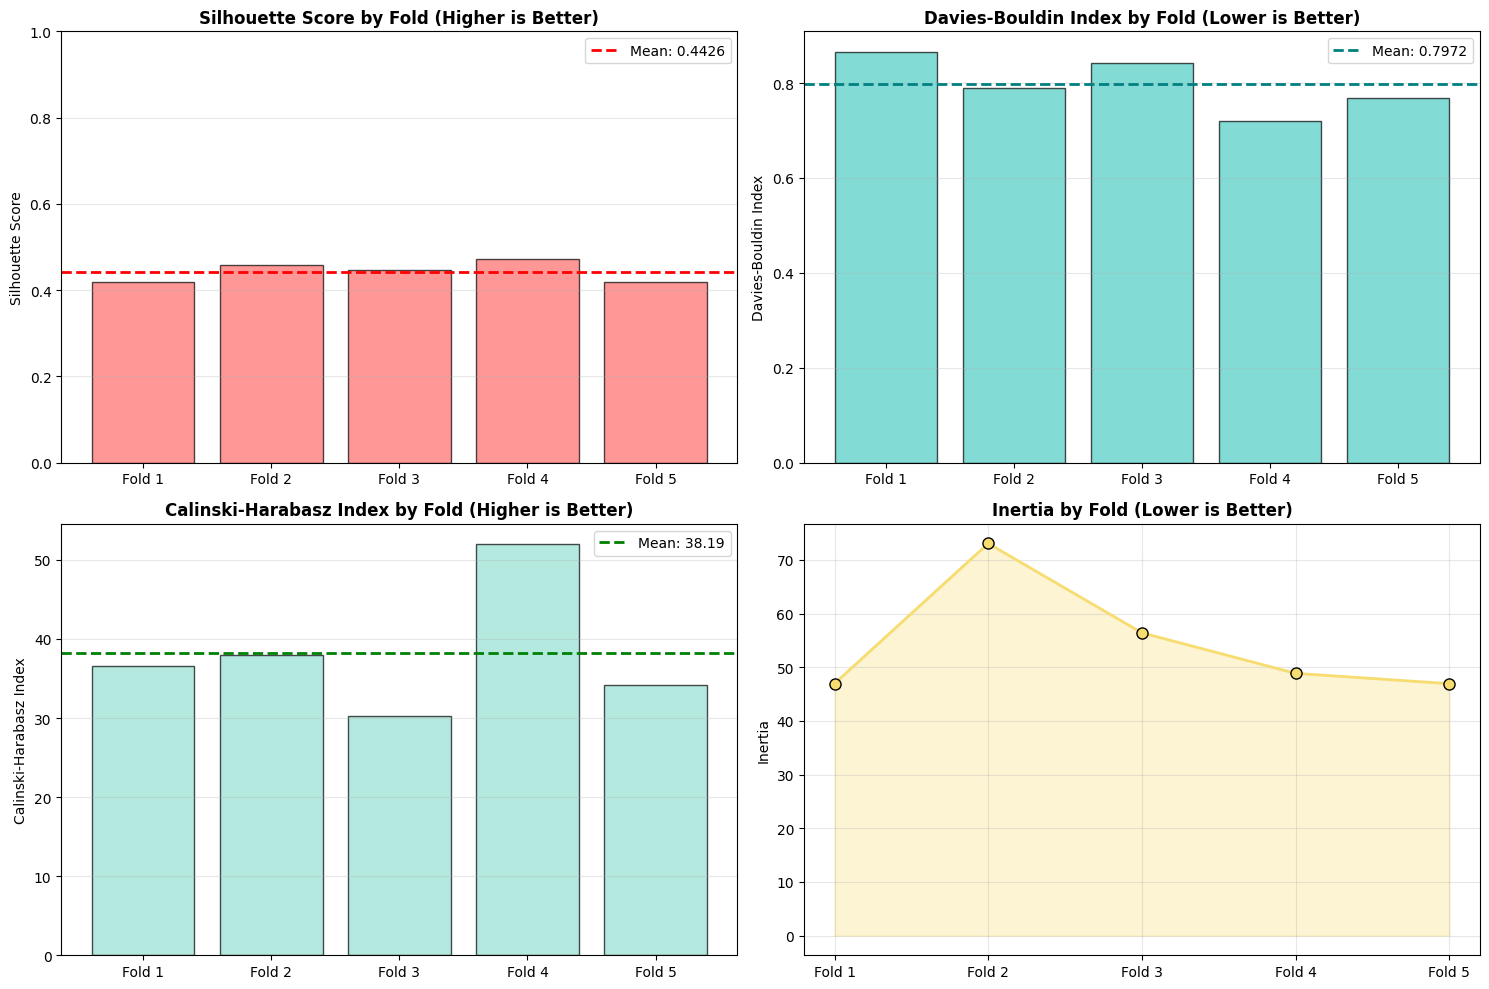

In [127]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 8.1 - Silhouette Score by Fold
ax = axes[0, 0]
folds = [f'Fold {i+1}' for i in range(len(silhouette_scores))]
x_pos = np.arange(len(folds))
ax.bar(x_pos, silhouette_scores, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(silhouette_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(silhouette_scores):.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette Score by Fold (Higher is Better)', fontsize=12, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.2 - Davies-Bouldin Index by Fold
ax = axes[0, 1]
ax.bar(x_pos, davies_bouldin_scores, color='#4ECDC4', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(davies_bouldin_scores), color='teal', linestyle='--', linewidth=2, label=f'Mean: {np.mean(davies_bouldin_scores):.4f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Davies-Bouldin Index')
ax.set_title('Davies-Bouldin Index by Fold (Lower is Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.3 - Calinski-Harabasz Index by Fold
ax = axes[1, 0]
ax.bar(x_pos, calinski_harabasz_scores, color='#95E1D3', alpha=0.7, edgecolor='black')
ax.axhline(y=np.mean(calinski_harabasz_scores), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(calinski_harabasz_scores):.2f}')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Calinski-Harabasz Index')
ax.set_title('Calinski-Harabasz Index by Fold (Higher is Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.legend()

# 8.4 - Inertia by Fold
ax = axes[1, 1]
ax.plot(x_pos, inertias, marker='o', linewidth=2, markersize=8, color='#F7DC6F', markeredgecolor='black')
ax.fill_between(x_pos, inertias, alpha=0.3, color='#F7DC6F')
ax.set_xticks(x_pos)
ax.set_xticklabels(folds)
ax.set_ylabel('Inertia')
ax.set_title('Inertia by Fold (Lower is Better)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('clustering_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

#print("Visualization completed and saved as 'clustering_evaluation.png'")

In [128]:
# Create table to store results from different methods
import pandas as pd

# Initialize results table with K-Means KFold results using helper function
results_table = pd.DataFrame()
results_table = add_results_to_table(results_table, kmeans_results, 'K-Means KFold')

print("Clustering Methods Comparison:")

results_table

Clustering Methods Comparison:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Train Time (s),Predict Time (s),Inertia
K-Means KFold,0.4426 (0.0212),0.7972 (0.0519),38.19 (7.36),0.027524 (0.042357),0.000191 (0.000056),54.45 (9.94)


## 9. K-Medoids with 5-Fold Cross Validation

In [129]:
# Run K-Medoids with helper function
kmedoids_results = run_kmedoids_kfold(X, cv, n_clusters=n_clusters, scaler_class=RobustScaler, method_name='K-Medoids')

# Store results in individual variables for backward compatibility
kmedoids_silhouette_scores = kmedoids_results['silhouette_scores']
kmedoids_davies_bouldin_scores = kmedoids_results['davies_bouldin_scores']
kmedoids_calinski_harabasz_scores = kmedoids_results['calinski_harabasz_scores']
kmedoids_train_times = kmedoids_results['train_times']
kmedoids_predict_times = kmedoids_results['predict_times']
kmedoids_inertias = kmedoids_results['inertias']

Running 5-Fold Cross Validation with K-Medoids (k=3)...

CROSS-VALIDATION SUMMARY - K-MEDOIDS
Silhouette Score: 0.4448 (+/- 0.0159)
Davies-Bouldin Index: 0.7861 (+/- 0.0406)
Calinski-Harabasz Index: 38.2296 (+/- 6.5958)
Avg Training Time: 0.006946s
Avg Prediction Time: 0.001231s


In [130]:
# Add K-Medoids results to the comparison table using helper function
results_table = add_results_to_table(results_table, kmedoids_results, 'K-Medoids KFold')

print("Clustering Methods Comparison:")

results_table

Clustering Methods Comparison:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Train Time (s),Predict Time (s),Inertia
K-Means KFold,0.4426 (0.0212),0.7972 (0.0519),38.19 (7.36),0.027524 (0.042357),0.000191 (0.000056),54.45 (9.94)
K-Medoids KFold,0.4448 (0.0159),0.7861 (0.0406),38.23 (6.60),0.006946 (0.002883),0.001231 (0.000316),71.57 (5.85)


## 10. Hierarchical Clustering with 5-Fold Cross Validation

In [131]:
# Run Hierarchical clustering with helper function
hierarchical_results = run_hierarchical_kfold(X, cv, n_clusters=n_clusters, scaler_class=RobustScaler, linkage='ward', method_name='Hierarchical')

# Store results in individual variables for backward compatibility
hierarchical_silhouette_scores = hierarchical_results['silhouette_scores']
hierarchical_davies_bouldin_scores = hierarchical_results['davies_bouldin_scores']
hierarchical_calinski_harabasz_scores = hierarchical_results['calinski_harabasz_scores']
hierarchical_train_times = hierarchical_results['train_times']
hierarchical_predict_times = hierarchical_results['predict_times']

Running 5-Fold Cross Validation with Hierarchical (k=3, linkage=ward)...

CROSS-VALIDATION SUMMARY - HIERARCHICAL
Silhouette Score: 0.4624 (+/- 0.0345)
Davies-Bouldin Index: 0.7602 (+/- 0.0921)
Calinski-Harabasz Index: 38.5223 (+/- 9.5531)
Avg Training Time: 0.002661s
Avg Prediction Time: 0.001403s


In [132]:
# Add Hierarchical Clustering results to the comparison table using helper function
results_table = add_results_to_table(results_table, hierarchical_results, 'Hierarchical KFold', include_inertia=False)

print("Clustering Methods Comparison:")

results_table

Clustering Methods Comparison:


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Train Time (s),Predict Time (s),Inertia
K-Means KFold,0.4426 (0.0212),0.7972 (0.0519),38.19 (7.36),0.027524 (0.042357),0.000191 (0.000056),54.45 (9.94)
K-Medoids KFold,0.4448 (0.0159),0.7861 (0.0406),38.23 (6.60),0.006946 (0.002883),0.001231 (0.000316),71.57 (5.85)
Hierarchical KFold,0.4624 (0.0345),0.7602 (0.0921),38.52 (9.55),0.002661 (0.001175),0.001403 (0.000678),N/A


## 11. Testing different scalers

In [133]:
# Run K-Means with different scalers

# K-Means with StandardScaler (default)
results = run_kmeans_kfold(X, cv, n_clusters=3, scaler_class=StandardScaler, method_name='K-Means (StandardScaler)')
results_table = add_results_to_table(results_table, results, 'K-Means (StandardScaler)')

# K-Medoids with StandardScaler
results = run_kmedoids_kfold(X, cv, n_clusters=3, scaler_class=StandardScaler, method_name='K-Medoids (StandardScaler)')
results_table = add_results_to_table(results_table, results, 'K-Medoids (StandardScaler)')

# Hierarchical with different linkage methods
results = run_hierarchical_kfold(X, cv, n_clusters=3, scaler_class=StandardScaler, linkage='ward', method_name='Hierarchical (StandardScaler)')
results_table = add_results_to_table(results_table, results, 'Hierarchical (StandardScaler)', include_inertia=False)

# K-Means with MinMaxScaler (default)
results = run_kmeans_kfold(X, cv, n_clusters=3, scaler_class=MinMaxScaler, method_name='K-Means (MinMaxScaler)')
results_table = add_results_to_table(results_table, results, 'K-Means (MinMaxScaler)')

# K-Medoids with MinMaxScaler
results = run_kmedoids_kfold(X, cv, n_clusters=3, scaler_class=MinMaxScaler, method_name='K-Medoids (MinMaxScaler)')
results_table = add_results_to_table(results_table, results, 'K-Medoids (MinMaxScaler)')

# Hierarchical with different linkage methods
results = run_hierarchical_kfold(X, cv, n_clusters=3, scaler_class=MinMaxScaler, linkage='ward', method_name='Hierarchical (MinMaxScaler)')
results_table = add_results_to_table(results_table, results, 'Hierarchical (MinMaxScaler)', include_inertia=False)


print("\n\nFinal Comparison Table:")
print("=" * 120)
results_table

Running 5-Fold Cross Validation with K-Means (StandardScaler) (k=3)...



CROSS-VALIDATION SUMMARY - K-MEANS (STANDARDSCALER)
Silhouette Score: 0.4655 (+/- 0.0373)
Davies-Bouldin Index: 0.7984 (+/- 0.0837)
Calinski-Harabasz Index: 49.6682 (+/- 12.1033)
Avg Training Time: 0.026162s
Avg Prediction Time: 0.000393s
Running 5-Fold Cross Validation with K-Medoids (StandardScaler) (k=3)...

CROSS-VALIDATION SUMMARY - K-MEDOIDS (STANDARDSCALER)
Silhouette Score: 0.4516 (+/- 0.0291)
Davies-Bouldin Index: 0.8058 (+/- 0.0759)
Calinski-Harabasz Index: 47.7475 (+/- 10.8187)
Avg Training Time: 0.002780s
Avg Prediction Time: 0.000565s
Running 5-Fold Cross Validation with Hierarchical (StandardScaler) (k=3, linkage=ward)...

CROSS-VALIDATION SUMMARY - HIERARCHICAL (STANDARDSCALER)
Silhouette Score: 0.4808 (+/- 0.0515)
Davies-Bouldin Index: 0.7094 (+/- 0.0533)
Calinski-Harabasz Index: 47.1323 (+/- 12.7483)
Avg Training Time: 0.000569s
Avg Prediction Time: 0.000303s
Running 5-Fold Cross Validation with K-Means (MinMaxScaler) (k=3)...

CROSS-VALIDATION SUMMARY - K-MEANS (MINMA

,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Train Time (s),Predict Time (s),Inertia
K-Means KFold,0.4426 (0.0212),0.7972 (0.0519),38.19 (7.36),0.027524 (0.042357),0.000191 (0.000056),54.45 (9.94)
K-Medoids KFold,0.4448 (0.0159),0.7861 (0.0406),38.23 (6.60),0.006946 (0.002883),0.001231 (0.000316),71.57 (5.85)
Hierarchical KFold,0.4624 (0.0345),0.7602 (0.0921),38.52 (9.55),0.002661 (0.001175),0.001403 (0.000678),N/A
K-Means (StandardScaler),0.4655 (0.0373),0.7984 (0.0837),49.67 (12.10),0.026162 (0.028607),0.000393 (0.000246),111.58 (2.19)
K-Medoids (StandardScaler),0.4516 (0.0291),0.8058 (0.0759),47.75 (10.82),0.002780 (0.000473),0.000565 (0.000160),104.36 (1.27)
Hierarchical (StandardScaler),0.4808 (0.0515),0.7094 (0.0533),47.13 (12.75),0.000569 (0.000235),0.000303 (0.000073),N/A
K-Means (MinMaxScaler),0.4934 (0.0349),0.7745 (0.1170),69.83 (15.47),0.004877 (0.000305),0.000156 (0.000019),5.79 (0.25)
K-Medoids (MinMaxScaler),0.4736 (0.0243),0.7584 (0.0807),65.41 (10.30),0.003406 (0.000738),0.000901 (0.000135),24.09 (0.57)
Hierarchical (MinMaxScaler),0.5187 (0.0430),0.6976 (0.0550),70.77 (12.17),0.000840 (0.000200),0.000412 (0.000065),N/A


In [134]:
# Sort results table by Calinski-Harabasz Index (descending - higher is better)
# Extract numeric value from the "mean (std)" format for sorting
sorted_table = results_table.copy()
sorted_table['CH_numeric'] = sorted_table['Calinski-Harabasz Index'].apply(
    lambda x: float(x.split(' ')[0]) if x != 'N/A' else -1
)
sorted_table = sorted_table.sort_values('CH_numeric', ascending=False).drop('CH_numeric', axis=1)

print("=" * 120)
print("CLUSTERING METHODS COMPARISON - SORTED BY CALINSKI-HARABASZ INDEX (Higher is Better)")
print("=" * 120)
sorted_table

CLUSTERING METHODS COMPARISON - SORTED BY CALINSKI-HARABASZ INDEX (Higher is Better)


,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Train Time (s),Predict Time (s),Inertia
Hierarchical (MinMaxScaler),0.5187 (0.0430),0.6976 (0.0550),70.77 (12.17),0.000840 (0.000200),0.000412 (0.000065),N/A
K-Means (MinMaxScaler),0.4934 (0.0349),0.7745 (0.1170),69.83 (15.47),0.004877 (0.000305),0.000156 (0.000019),5.79 (0.25)
K-Medoids (MinMaxScaler),0.4736 (0.0243),0.7584 (0.0807),65.41 (10.30),0.003406 (0.000738),0.000901 (0.000135),24.09 (0.57)
K-Means (StandardScaler),0.4655 (0.0373),0.7984 (0.0837),49.67 (12.10),0.026162 (0.028607),0.000393 (0.000246),111.58 (2.19)
K-Medoids (StandardScaler),0.4516 (0.0291),0.8058 (0.0759),47.75 (10.82),0.002780 (0.000473),0.000565 (0.000160),104.36 (1.27)
Hierarchical (StandardScaler),0.4808 (0.0515),0.7094 (0.0533),47.13 (12.75),0.000569 (0.000235),0.000303 (0.000073),N/A
Hierarchical KFold,0.4624 (0.0345),0.7602 (0.0921),38.52 (9.55),0.002661 (0.001175),0.001403 (0.000678),N/A
K-Medoids KFold,0.4448 (0.0159),0.7861 (0.0406),38.23 (6.60),0.006946 (0.002883),0.001231 (0.000316),71.57 (5.85)
K-Means KFold,0.4426 (0.0212),0.7972 (0.0519),38.19 (7.36),0.027524 (0.042357),0.000191 (0.000056),54.45 (9.94)
